# 03 · AHP multi-criteria baseline

The Analytic Hierarchy Process (Saaty, 1980) is the classic GIS approach to site suitability:

1. experts compare criteria pairwise on a 1-9 scale → matrix **A** with $a_{ji} = 1/a_{ij}$
2. weights **w** = principal eigenvector of **A** (normalised)
3. consistency: $CI = (\lambda_{max} - n)/(n-1)$, $CR = CI/RI$; accept if $CR < 0.10$
4. each criterion is rescaled to [0, 1] by a fuzzy membership function
5. suitability $= 100 \cdot \sum_i w_i s_i \times$ constraint mask (water, wetland, built-up, snow, slope > 15°)

All inputs come from cached data (decoded Earth Engine rasters for Tamil Nadu, the 0.5° grid globally).

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from model import config
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

from model import ahp, viz
from IPython.display import Image, display
viz.apply_style()

In [2]:
res = ahp.main()
for key in ('tamil_nadu', 'global'):
    r = res[key]
    print(f"{key}: lambda_max = {r['lambda_max']:.3f}, CI = {r['CI']:.4f}, RI = {r['RI']}, CR = {r['CR']:.4f}")

[ahp] Tamil Nadu: lambda_max=7.130 CI=0.0216 CR=0.0164
        GHI                 31.6%
        Slope               19.8%
        Land cover          19.8%
        Dist. substation    12.3%
        NDVI                 7.8%
        Dist. road           5.1%
        Air temperature      3.5%


[ahp] Global: lambda_max=6.072 CI=0.0144 CR=0.0116
        GHI                 34.2%
        Slope               20.6%
        Land cover          20.6%
        Accessibility       12.2%
        NDVI                 7.5%
        Air temperature      4.9%


[ahp] tamil_nadu map: mean 59.4, excluded 10.5%, high (>=70) 39.1%
[ahp] global map: mean 46.4, excluded 18.3%, high (>=70) 27.5%
tamil_nadu: lambda_max = 7.130, CI = 0.0216, RI = 1.32, CR = 0.0164
global: lambda_max = 6.072, CI = 0.0144, RI = 1.24, CR = 0.0116


## Tamil Nadu

In [3]:
r = res['tamil_nadu']
display(pd.DataFrame(r['matrix'], index=r['criteria'], columns=r['criteria']).round(3))
display(pd.DataFrame({'weight': r['weights'], 'standardisation': r['standardisation']}))

,GHI,Slope,Land cover,Dist. substation,Dist. road,NDVI,Air temperature
GHI,1.000,2.000,2.000,3.000,5.0,4.000,6.0
Slope,0.500,1.000,1.000,2.000,4.0,3.000,5.0
Land cover,0.500,1.000,1.000,2.000,4.0,3.000,5.0
Dist. substation,0.333,0.500,0.500,1.000,3.0,2.000,4.0
Dist. road,0.200,0.250,0.250,0.333,1.0,0.500,2.0
NDVI,0.250,0.333,0.333,0.500,2.0,1.000,3.0
Air temperature,0.167,0.200,0.200,0.250,0.5,0.333,1.0


,weight,standardisation
GHI,0.3164,"benefit, 4.5 -> 5.8 kWh/m²/day"
Slope,0.1983,"cost, 0 -> 10°"
Land cover,0.1983,"look-up (bare 1.0, grass 0.9, shrub 0.8, crop ..."
Dist. substation,0.1228,"cost, 0 -> 20 km"
Dist. road,0.0510,"cost, 0 -> 5 km"
NDVI,0.0782,"cost, 0.1 -> 0.6"
Air temperature,0.0350,"cost, 25 -> 35 °C"


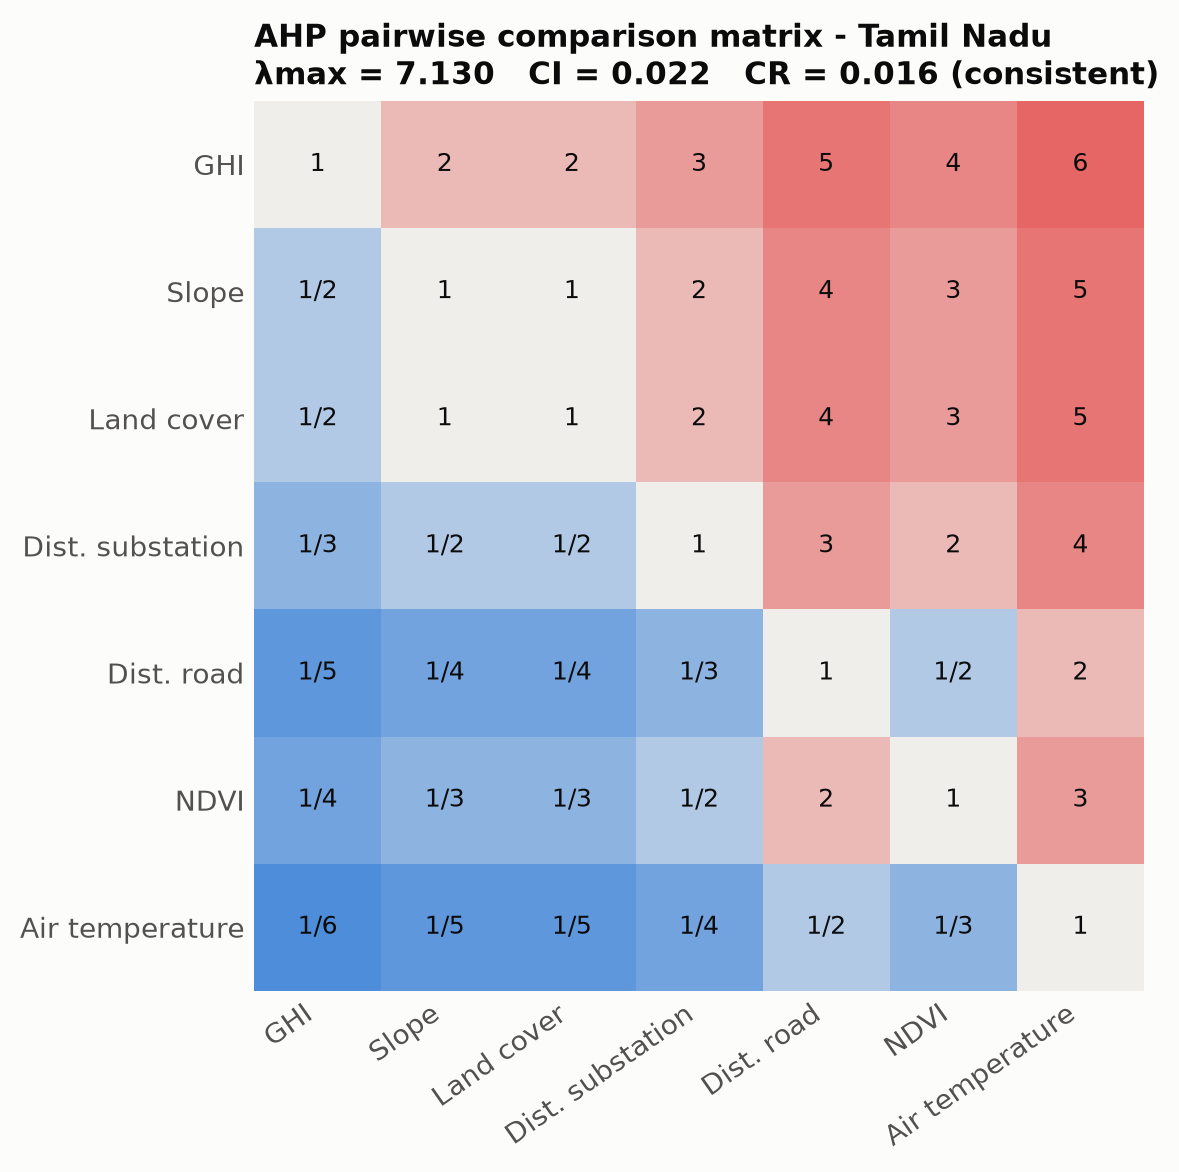

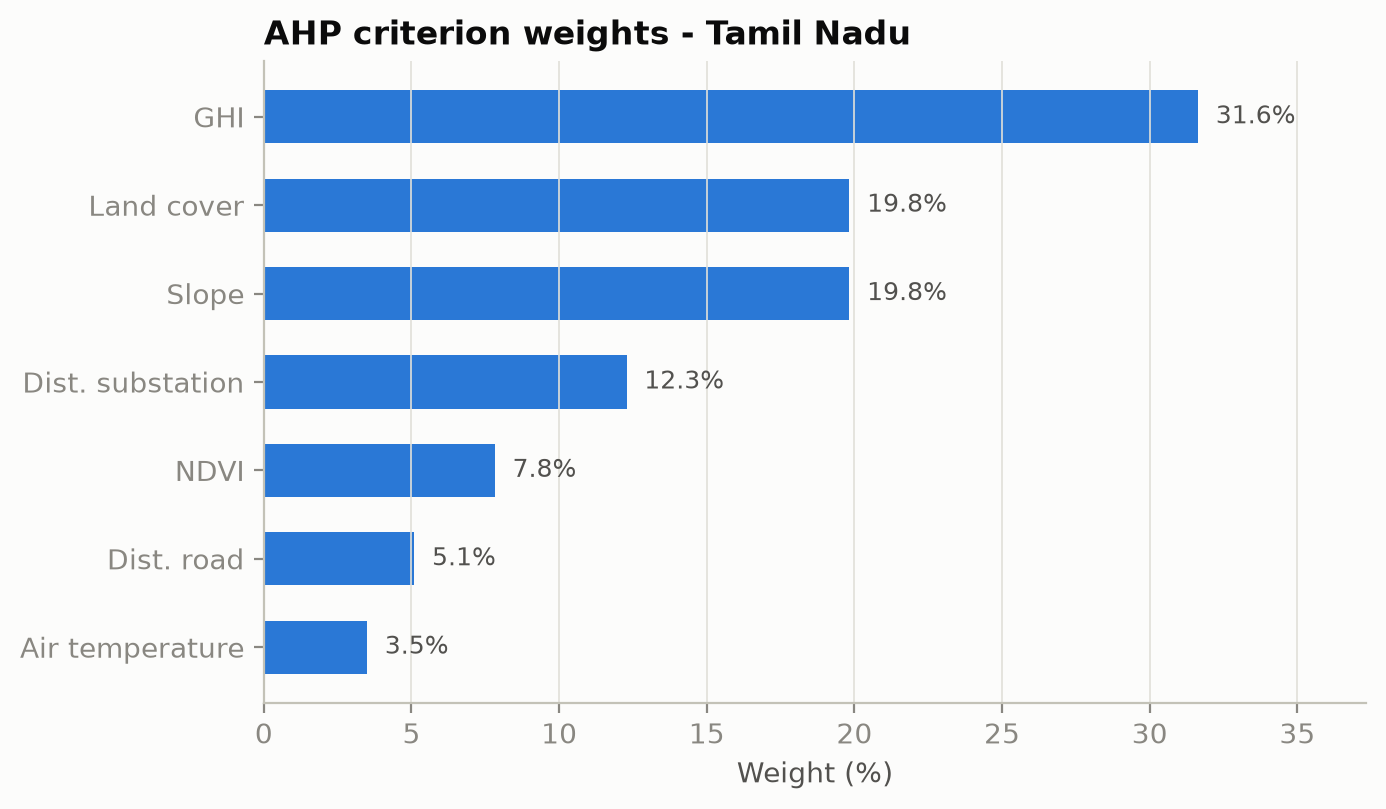

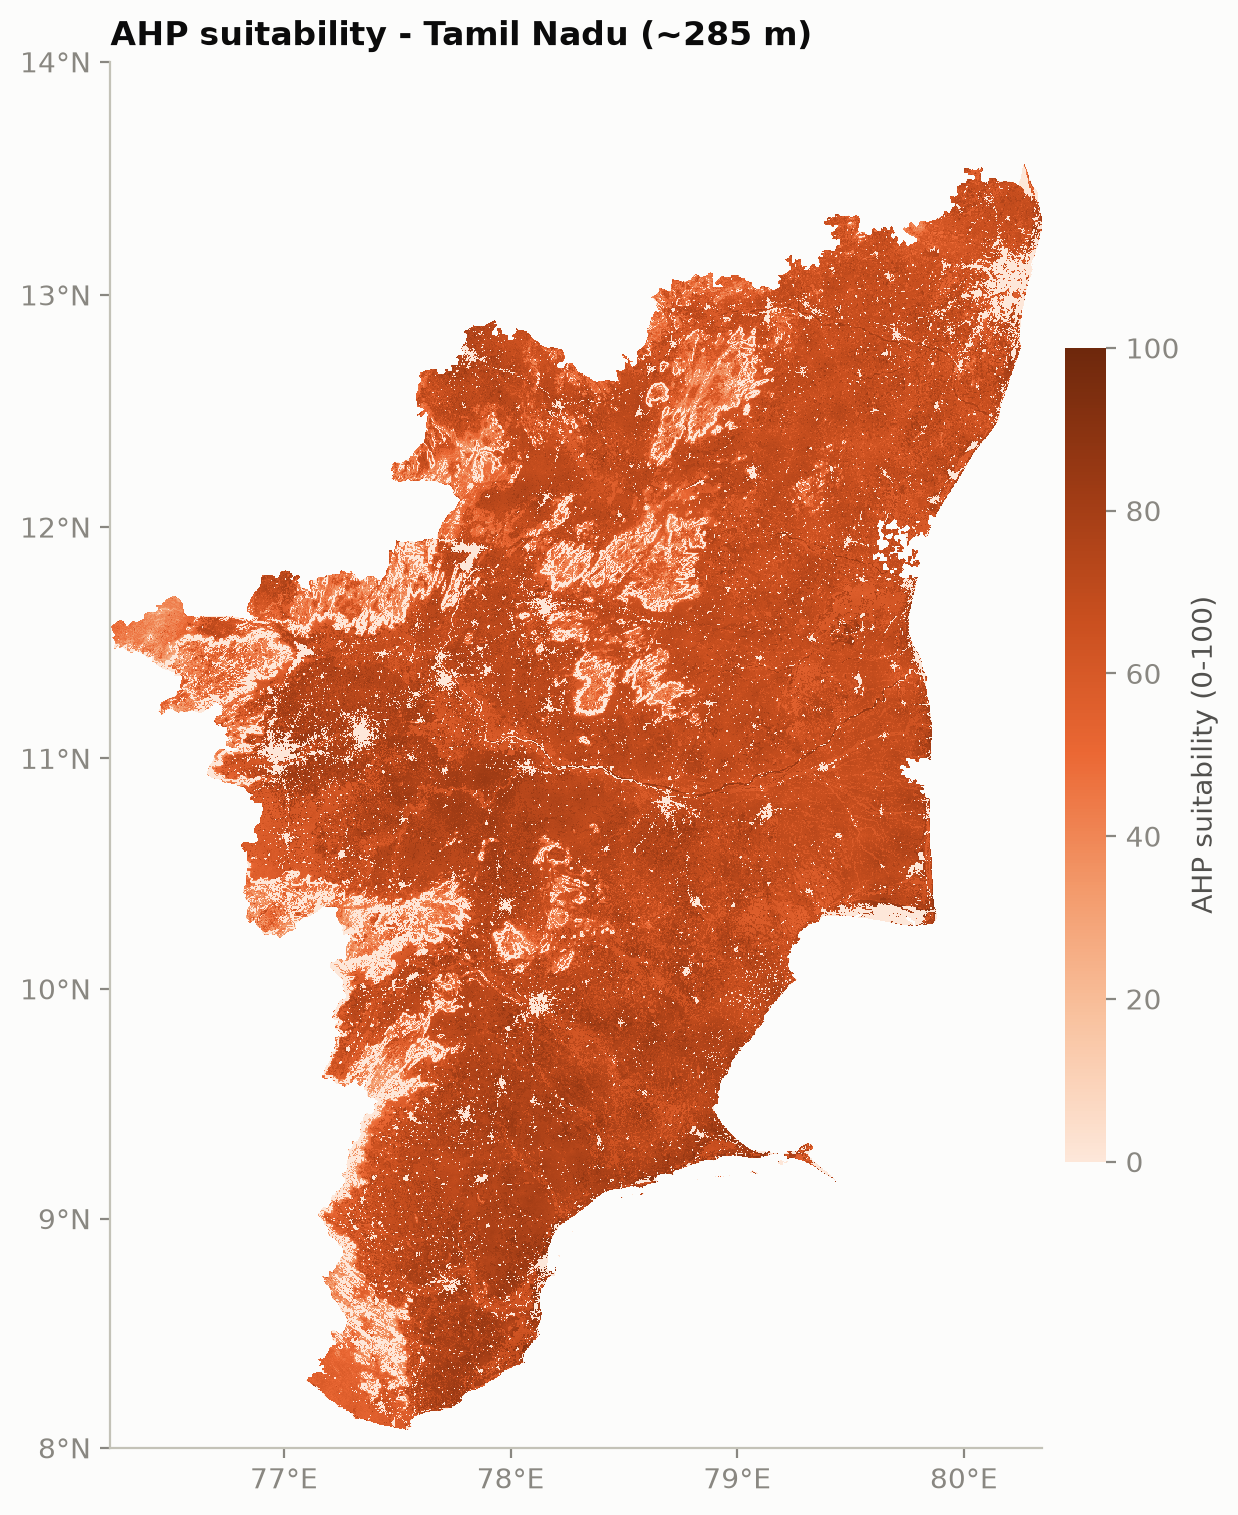

In [4]:
display(Image(str(config.FIGURES_DIR / 'ahp_matrix_tamil_nadu.png'), width=620))
display(Image(str(config.FIGURES_DIR / 'ahp_weights_tamil_nadu.png'), width=560))
display(Image(str(config.FIGURES_DIR / 'ahp_map_tamil_nadu.png'), width=560))

## Global

,GHI,Slope,Land cover,Accessibility,NDVI,Air temperature
GHI,1.000,2.000,2.000,3.000,4.0,5.0
Slope,0.500,1.000,1.000,2.000,3.0,4.0
Land cover,0.500,1.000,1.000,2.000,3.0,4.0
Accessibility,0.333,0.500,0.500,1.000,2.0,3.0
NDVI,0.250,0.333,0.333,0.500,1.0,2.0
Air temperature,0.200,0.250,0.250,0.333,0.5,1.0


,weight,standardisation
GHI,0.3422,"benefit, 2.5 -> 6.5 kWh/m²/day"
Slope,0.2057,"cost, 0 -> 10°"
Land cover,0.2057,"IGBP look-up (barren 1.0, grass/open shrub 0.9..."
Accessibility,0.1219,"cost, 30 -> 360 min to nearest city"
NDVI,0.0753,"cost, 0.1 -> 0.7"
Air temperature,0.0492,"trapezoid: 0 at -10 °C, 1 between 10-25 °C, 0 ..."


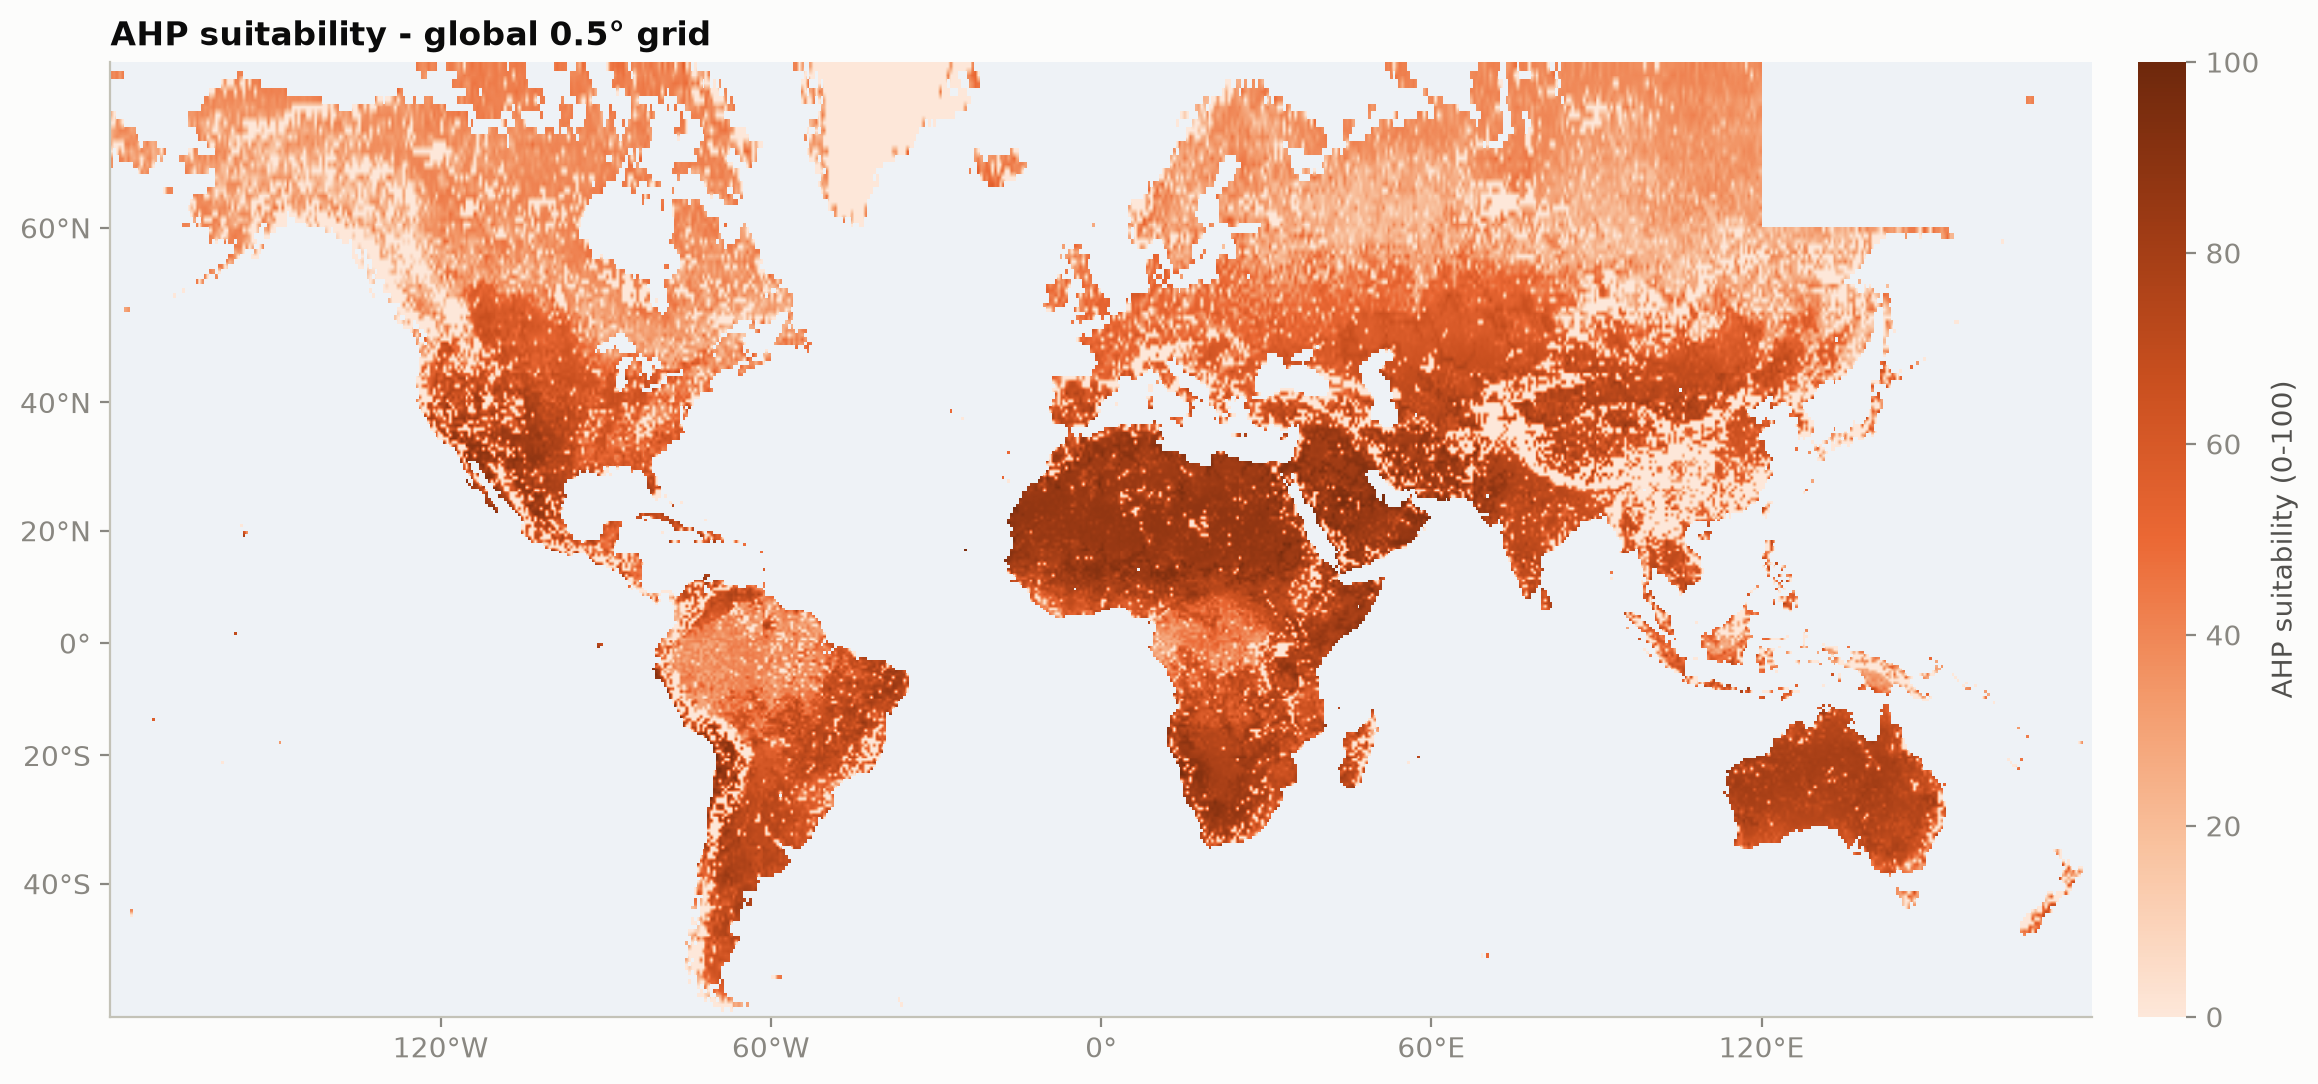

In [5]:
r = res['global']
display(pd.DataFrame(r['matrix'], index=r['criteria'], columns=r['criteria']).round(3))
display(pd.DataFrame({'weight': r['weights'], 'standardisation': r['standardisation']}))
display(Image(str(config.FIGURES_DIR / 'ahp_map_global.png'), width=1000))

## How well does AHP rank real solar plants?

In [6]:
from sklearn.metrics import roc_auc_score
for name, path in (('Tamil Nadu', 'tn_ahp_points.csv'), ('Global', 'global_ahp_points.csv')):
    d = pd.read_csv(config.PROCESSED_DIR / path)
    print(f"{name}: AUC of AHP score vs plant labels = {roc_auc_score(d.label, d.ahp_score.fillna(0)):.3f}  "
          f"(mean score plants {d[d.label == 1].ahp_score.mean():.1f} vs non-plants {d[d.label == 0].ahp_score.mean():.1f})")

Tamil Nadu: AUC of AHP score vs plant labels = 0.813  (mean score plants 71.3 vs non-plants 56.7)
Global: AUC of AHP score vs plant labels = 0.621  (mean score plants 63.8 vs non-plants 51.0)


AHP encodes *physical* potential with expert weights. It ranks Tamil Nadu plants reasonably well but is
weak globally: it rewards the Sahara, Arabia and central Australia, where almost no utility PV has been built
because there is no grid or demand nearby. Phase 3 shows how data-driven models close this gap.